# Latent Factor Model Suite for US Firm Characteristics

This index reconciles the complete validation surfaces produced by the US Firm latent-model
notebooks. It does not fit a model or open the holdout.

**Learning objectives**

- Confirm that each eligible latent producer has one complete corrected identity.
- Compare each model at its global development checkpoint across all folds.
- Preserve every complete checkpoint as a downstream strategy candidate.

**Book reference:** Chapter 14, latent factor models and the objective comparison.

**Prerequisites:** `08b_conditional_autoencoder`, `08c_stochastic_discount_factor`, and
`08d_supervised_autoencoder`. `08a_ipca` is an approved deferred publication exception because
the installed solver does not satisfy the corrected convergence contract.

In [1]:
"""Latent factor notebook index for the US firm characteristics case study."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

from case_studies.utils import registry
from utils.style import COLORS, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
LABEL = "fwd_ret_1m"
EXPECTED_CHECKPOINTS = {"cae": 10, "sdf": 5, "sae": 10}

## Load the corrected latent surface

The live candidate contains only the three eligible corrected producers. IPCA is not represented
by a stale or unverified row. Each physical checkpoint combines the same epoch across every
validation fold.

In [3]:
training_runs = registry.load_training_runs(
    CASE_STUDY_ID,
    family="latent_factors",
    label=LABEL,
)
prediction_sets = registry.load_prediction_sets(CASE_STUDY_ID, split="validation")
prediction_metrics = registry.load_prediction_metrics(CASE_STUDY_ID)

surface = (
    training_runs.select("training_hash", "config_name", "entry_point")
    .join(prediction_sets, on="training_hash", how="inner")
    .join(prediction_metrics, on="prediction_hash", how="inner")
    .sort("config_name", "checkpoint_value")
)
models = set(surface["config_name"].unique().to_list())
if models != set(EXPECTED_CHECKPOINTS):
    raise ValueError(f"Expected {set(EXPECTED_CHECKPOINTS)}, found {models}")

print(f"Corrected latent identities: {training_runs.height}")
print(f"Physical checkpoint surfaces: {surface.height}")
print("IPCA status: deferred; no stale result admitted")

Corrected latent identities: 3
Physical checkpoint surfaces: 25
IPCA status: deferred; no stale result admitted


## Verify completeness before comparison

A model enters the comparison only when every physical checkpoint covers all ten folds and all
110 validation months. This excludes partial training and interrupted artifacts.

In [4]:
completeness = (
    surface.group_by("config_name")
    .agg(
        pl.col("training_hash").n_unique().alias("training_identities"),
        pl.col("prediction_hash").n_unique().alias("checkpoints"),
        pl.col("ic_n_days").min().alias("min_months"),
        pl.col("ic_n_days").max().alias("max_months"),
        pl.col("checkpoint_value").sort().alias("physical_checkpoints"),
    )
    .sort("config_name")
)
for row in completeness.iter_rows(named=True):
    expected = EXPECTED_CHECKPOINTS[row["config_name"]]
    if row["training_identities"] != 1 or row["checkpoints"] != expected:
        raise ValueError(f"Incomplete {row['config_name']} surface: {row}")
    if row["min_months"] != 110 or row["max_months"] != 110:
        raise ValueError(f"Incomplete validation coverage: {row}")
completeness

config_name,training_identities,checkpoints,min_months,max_months,physical_checkpoints
str,u32,u32,f64,f64,list[i64]
"""cae""",1,10,110.0,110.0,"[5, 10, … 50]"
"""sae""",1,10,110.0,110.0,"[5, 10, … 50]"
"""sdf""",1,5,110.0,110.0,"[256, 512, … 1280]"


## Direct supervision leads the latent objectives

The comparison selects one global development checkpoint per model after combining every fold at
the same physical epoch. It does not create a fold-specific best-checkpoint composite. All 25
checkpoint surfaces remain eligible for the equal-weight baseline backtest.

In [5]:
best_by_model = (
    surface.sort("ic_mean_daily", descending=True)
    .group_by("config_name", maintain_order=True)
    .first()
    .sort("ic_mean_daily")
    .select(
        "config_name",
        pl.col("checkpoint_value").alias("epoch"),
        "prediction_hash",
        "ic_mean_daily",
        "ic_ci_lo",
        "ic_ci_hi",
        "ic_p_hac",
        "ic_n_days",
    )
)
best_by_model

config_name,epoch,prediction_hash,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_p_hac,ic_n_days
str,i64,str,f64,f64,f64,f64,f64
"""cae""",10,"""5f36e996d490""",-0.030129,-0.051573,-0.008686,0.006318,110.0
"""sdf""",1280,"""29a42a6b4798""",0.022554,-0.002767,0.047876,0.080298,110.0
"""sae""",15,"""4f7eaeb2dff6""",0.061974,0.03548,0.088467,0.00001,110.0


HAC intervals distinguish a stable positive ranking signal from a nominal point estimate. The
chart compares model objectives without suppressing their other checkpoint candidates.

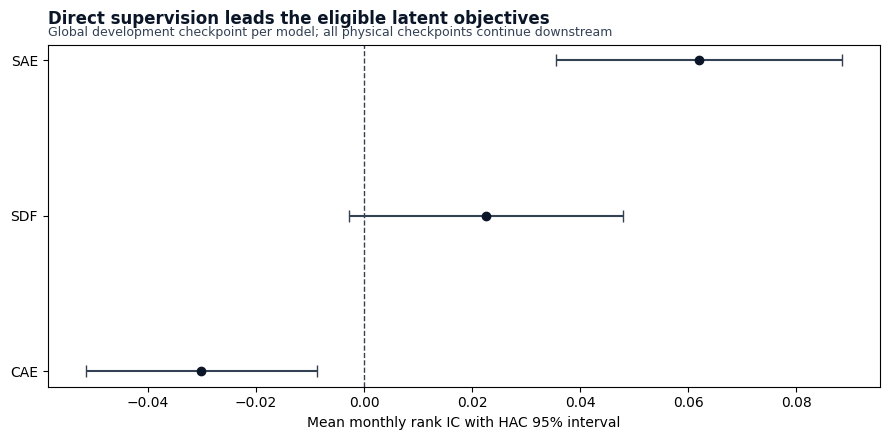

In [6]:
y = np.arange(best_by_model.height)
means = best_by_model["ic_mean_daily"].to_numpy()
lower = means - best_by_model["ic_ci_lo"].to_numpy()
upper = best_by_model["ic_ci_hi"].to_numpy() - means

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(
    means,
    y,
    xerr=[lower, upper],
    fmt="o",
    color=COLORS["blue"],
    ecolor=COLORS["neutral"],
    capsize=4,
)
ax.axvline(0, color=COLORS["neutral"], linewidth=1, linestyle="--")
ax.set(
    xlabel="Mean monthly rank IC with HAC 95% interval",
    yticks=y,
    yticklabels=[name.upper() for name in best_by_model["config_name"]],
)
add_message_title(
    ax,
    "Direct supervision leads the eligible latent objectives",
    subtitle="Global development checkpoint per model; all physical checkpoints continue downstream",
)
fig.tight_layout()
fig.show()

## Takeaways

This index closes the latent producer boundary without changing the downstream selection funnel.

In [7]:
leader = best_by_model.sort("ic_mean_daily", descending=True).row(0, named=True)
display(
    Markdown(
        f"""
- The corrected latent boundary contains **{training_runs.height}** eligible model identities and
  **{surface.height}** complete physical checkpoint surfaces; IPCA remains explicitly deferred.
- **{leader["config_name"].upper()} at epoch {int(leader["epoch"])}** leads development IC at
  **{leader["ic_mean_daily"]:+.4f}**, with HAC 95% interval
  **[{leader["ic_ci_lo"]:+.4f}, {leader["ic_ci_hi"]:+.4f}]** across
  **{int(leader["ic_n_days"])}** months.
- CAE, SDF, and SAE each contribute every complete checkpoint to `11_backtest`; this model-level
  comparison does not prune the strategy research surface.
- `09_causal_dml` adds a causal robustness diagnostic before `10_model_analysis` compares all model
  families. The sealed holdout remains untouched until the final carrier is selected.
"""
    )
)


- The corrected latent boundary contains **3** eligible model identities and
  **25** complete physical checkpoint surfaces; IPCA remains explicitly deferred.
- **SAE at epoch 15** leads development IC at
  **+0.0620**, with HAC 95% interval
  **[+0.0355, +0.0885]** across
  **110** months.
- CAE, SDF, and SAE each contribute every complete checkpoint to `11_backtest`; this model-level
  comparison does not prune the strategy research surface.
- `09_causal_dml` adds a causal robustness diagnostic before `10_model_analysis` compares all model
  families. The sealed holdout remains untouched until the final carrier is selected.
